In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch
import scanpy as sc
import pandas as pd
import ma_codes as codes
from ma_codes import mysize, gray_red, mymap
import pertpy as pt
import seaborn as sns
from pathlib import Path
import math
import re
import gseapy as gp

from matplotlib import colors
gray_red = colors.LinearSegmentedColormap.from_list("", ["lightgray", "red", "darkred"], N = 128)

sc.settings.verbosity = 3               # verbosity: errors (0), warnings (1), info (2), hints (3)
sc.logging.print_version_and_date()

Running Scanpy 1.11.4, on 2026-08-27 10:34.


In [2]:
plt.rcParams['pdf.fonttype'] = 42

In [3]:
plot_folder = "/media/synology/Huijuan/Plots/IPF_subsets/IPF_paper/MAST_EC_pathway/new/"

In [4]:
# ── 1. cell types, paths, colors ─────────────────────────────────────────────
cell_types = {
    "VWA1+/PLVAP+ bronchial EC":   "PLVAP_VWA1_EC",
    "aCap":            "aCap",
    "gCap":            "gCap",
    "Arterial EC":        "Arterial_EC",
    "Pulmonary venous EC":"Pulmonary_venous_EC",
    "LEC": "LEC"
}

# match your snRNA-seq UMAP colors for each cell type
cell_type_colors = {
    'Arterial EC':'#95bf6b',
    'LEC': '#e0e093',
    'gCap': '#CAB2D6', #'#f78b3b'
    'aCap': '#f3cfe2',
    'Pulmonary venous EC': '#a1cedd', #'#28a8c8',
    'VWA1+/PLVAP+ bronchial EC':'#E623B1', #'#e31a1c',   
}
ct_order = list(cell_types.keys())

In [5]:
base_dir = Path("/media/synology/Huijuan/Plots/IPF_subsets/IPF_paper")
gs_file  = "GO_Biological_Process_2025.Human.enrichr.reports.txt" 

## Upregulated pathways from GO 2025 database (biological process)

In [ ]:
terms_of_interest = [
    # PLVAP up
    "Endothelial Tube Morphogenesis",
    "Blood Vessel Morphogenesis",
    "Blood Vessel Endothelial Cell Migration",
    "Regulation of Vascular Endothelial Growth Factor Receptor Signaling Pathway",
    "Wound Healing",
    "Sprouting Angiogenesis",
    "Regulation of Chemokine-Mediated Signaling Pathway",
    "Regulation of Endothelial Cell Proliferation",
    
    #gCap up
    "Protein Ubiquitination",
    "Response to Endoplasmic Reticulum Stress",
    'Hippo Signaling',
    "ERAD Pathway",
    "Canonical NF-kappaB Signal Transduction",
    'Response to Laminar Fluid Shear Stress',
    "Regulation of Notch Signaling Pathway",
    "Venous Blood Vessel Development",
    "Cellular Response to Interleukin-4",
    
    
    # aCap up
    'Response to Interferon-Beta',
    'Cellular Response to Growth Factor Stimulus',
    "Transforming Growth Factor Beta Receptor Signaling Pathway",
    'Regulation of Angiogenesis',
    "Regulation of Canonical Wnt Signaling Pathway",
    "Regulation of Fibroblast Migration",
    "Regulation of Vasculature Development",
    
    
    # Arterial EC up
    "Regulation of Extracellular Matrix Assembly",
    "Positive Regulation of Extracellular Matrix Organization",

    
]
terms_of_interest = list(dict.fromkeys(terms_of_interest))

category_map = {

    # Angiogenesis & Vascular Development
    "Endothelial Tube Morphogenesis": "Angiogenesis & Vascular Development",
    "Blood Vessel Morphogenesis": "Angiogenesis & Vascular Development",
    "Blood Vessel Endothelial Cell Migration": "Angiogenesis & Vascular Development",
    "Sprouting Angiogenesis": "Angiogenesis & Vascular Development",
    "Regulation of Endothelial Cell Proliferation": "Angiogenesis & Vascular Development",
    "Venous Blood Vessel Development": "Angiogenesis & Vascular Development",
    "Regulation of Angiogenesis": "Angiogenesis & Vascular Development",
    "Regulation of Vasculature Development": "Angiogenesis & Vascular Development",
     "Wound Healing": "Angiogenesis & Vascular Development",

    # Growth Factor & Developmental Signaling
    "Regulation of Vascular Endothelial Growth Factor Receptor Signaling Pathway":
        "Growth Factor & Developmental Signaling",
    "Hippo Signaling": "Growth Factor & Developmental Signaling",
    "Regulation of Notch Signaling Pathway":
        "Growth Factor & Developmental Signaling",
    "Cellular Response to Growth Factor Stimulus":
        "Growth Factor & Developmental Signaling",
    "Transforming Growth Factor Beta Receptor Signaling Pathway":
        "Growth Factor & Developmental Signaling",
    "Regulation of Canonical Wnt Signaling Pathway":
        "Growth Factor & Developmental Signaling",

    # Inflammation & Immune Response
    "Regulation of Chemokine-Mediated Signaling Pathway":
        "Inflammation & Immune Response",
    "Canonical NF-kappaB Signal Transduction":
        "Inflammation & Immune Response",
    "Cellular Response to Interleukin-4":
        "Inflammation & Immune Response",
    "Response to Interferon-Beta":
        "Inflammation & Immune Response",


    # ECM Remodeling & EMT
    "Regulation of Fibroblast Migration": "ECM Remodeling & EMT",
    "Regulation of Extracellular Matrix Assembly":
        "ECM Remodeling & EMT",
    "Positive Regulation of Extracellular Matrix Organization":
        "ECM Remodeling & EMT",

    # Cellular Stress & Metabolism
    "Protein Ubiquitination": "Cellular Stress & Metabolism",
    "Response to Endoplasmic Reticulum Stress":
        "Cellular Stress & Metabolism",
    "ERAD Pathway": "Cellular Stress & Metabolism",
    "Response to Laminar Fluid Shear Stress":
        "Cellular Stress & Metabolism",
}

category_order = [
    "Angiogenesis & Vascular Development",
    "Growth Factor & Developmental Signaling",
    "Inflammation & Immune Response",
    "ECM Remodeling & EMT",
    "Cellular Stress & Metabolism"
]

category_colors = {
    "Angiogenesis & Vascular Development": '#fbb4ae',      # pink
    "Growth Factor & Developmental Signaling": "#b3cde3", # blue
    "Inflammation & Immune Response": "#ccebc5",          # green
    "ECM Remodeling & EMT": "#decbe4",                    # purple
    "Cellular Stress & Metabolism": "#fed9a6"             # yellow
}

In [7]:
# sanity check: every term has a category
missing_cat = [t for t in terms_of_interest if t not in category_map]
if missing_cat:
    print(f"WARNING: {len(missing_cat)} terms_of_interest have no category mapping:")
    for t in missing_cat:
        print(f"  - {t}")

In [8]:
# ── helpers (same as before) ──────────────────────────────────────────────────
def strip_go_id(s):
    return re.sub(r"\s*\(GO:\d+\)\s*$", "", s).strip()

def parse_overlap_ratio(x):
    """Parse enrichr 'Overlap' column ('k/n') and return ratio k/n."""
    try:
        parts = str(x).strip().split("/")
        k, n = int(parts[0]), int(parts[1])
        return k / n if n > 0 else np.nan
    except (ValueError, IndexError):
        return np.nan

def load_and_filter(path, terms):
    if not path.exists():
        print(f"  MISSING: {path}")
        return pd.DataFrame()
    df = pd.read_csv(path, delimiter="\t")
    df["Term_clean"]     = df["Term"].apply(strip_go_id)
    lookup               = {t.lower(): t for t in terms}
    df["Term_matched"]   = df["Term_clean"].str.lower().map(lookup)
    df                   = df.dropna(subset=["Term_matched"])
    df["overlap_ratio"]  = df["Overlap"].apply(parse_overlap_ratio)
    df                   = df.dropna(subset=["overlap_ratio"])
    return df

In [9]:
# ── 4. load all cell types × conditions ──────────────────────────────────────
records = []
for ct_label, ct_folder in cell_types.items():
    for condition, subfolder in [("Mild", "mild_up"), ("Severe", "severe_up")]:
        matches = list(base_dir.glob(f"{ct_folder}/{subfolder}/{gs_file}"))
        if not matches:
            matches = list(base_dir.glob(f"**/{ct_folder}/{subfolder}/{gs_file}"))
        if not matches:
            print(f"  NOT FOUND: {ct_label} / {condition}")
            continue
        df = load_and_filter(matches[0], terms_of_interest)
        if df.empty:
            print(f"  NO MATCHES: {ct_label} / {condition}")
            continue
        for _, row in df.iterrows():
            records.append({
                "cell_type":     ct_label,
                "condition":     condition,
                "Term":          row["Term_matched"],
                "pval":          row["P-value"],
                "overlap_ratio": row["overlap_ratio"],
            })
        print(f"  OK: {ct_label} / {condition} — {len(df)} terms matched")

plot_df = pd.DataFrame(records)
print(f"\nTotal rows: {len(plot_df)}")
print(plot_df.groupby(["cell_type", "condition"]).size().to_string())

  OK: VWA1+/PLVAP+ bronchial EC / Mild — 24 terms matched
  OK: VWA1+/PLVAP+ bronchial EC / Severe — 23 terms matched
  OK: aCap / Mild — 26 terms matched
  OK: aCap / Severe — 13 terms matched
  OK: gCap / Mild — 26 terms matched
  OK: gCap / Severe — 25 terms matched
  OK: Arterial EC / Mild — 23 terms matched
  OK: Arterial EC / Severe — 23 terms matched
  OK: Pulmonary venous EC / Mild — 26 terms matched
  OK: Pulmonary venous EC / Severe — 25 terms matched
  OK: LEC / Mild — 20 terms matched
  OK: LEC / Severe — 19 terms matched

Total rows: 273
cell_type                  condition
Arterial EC                Mild         23
                           Severe       23
LEC                        Mild         20
                           Severe       19
Pulmonary venous EC        Mild         26
                           Severe       25
VWA1+/PLVAP+ bronchial EC  Mild         24
                           Severe       23
aCap                       Mild         26
                   

### Differentiated pathway (up-regulated pathways)
overlap ratio (k/n) is more informative than raw gene count because it normalises for pathway size 

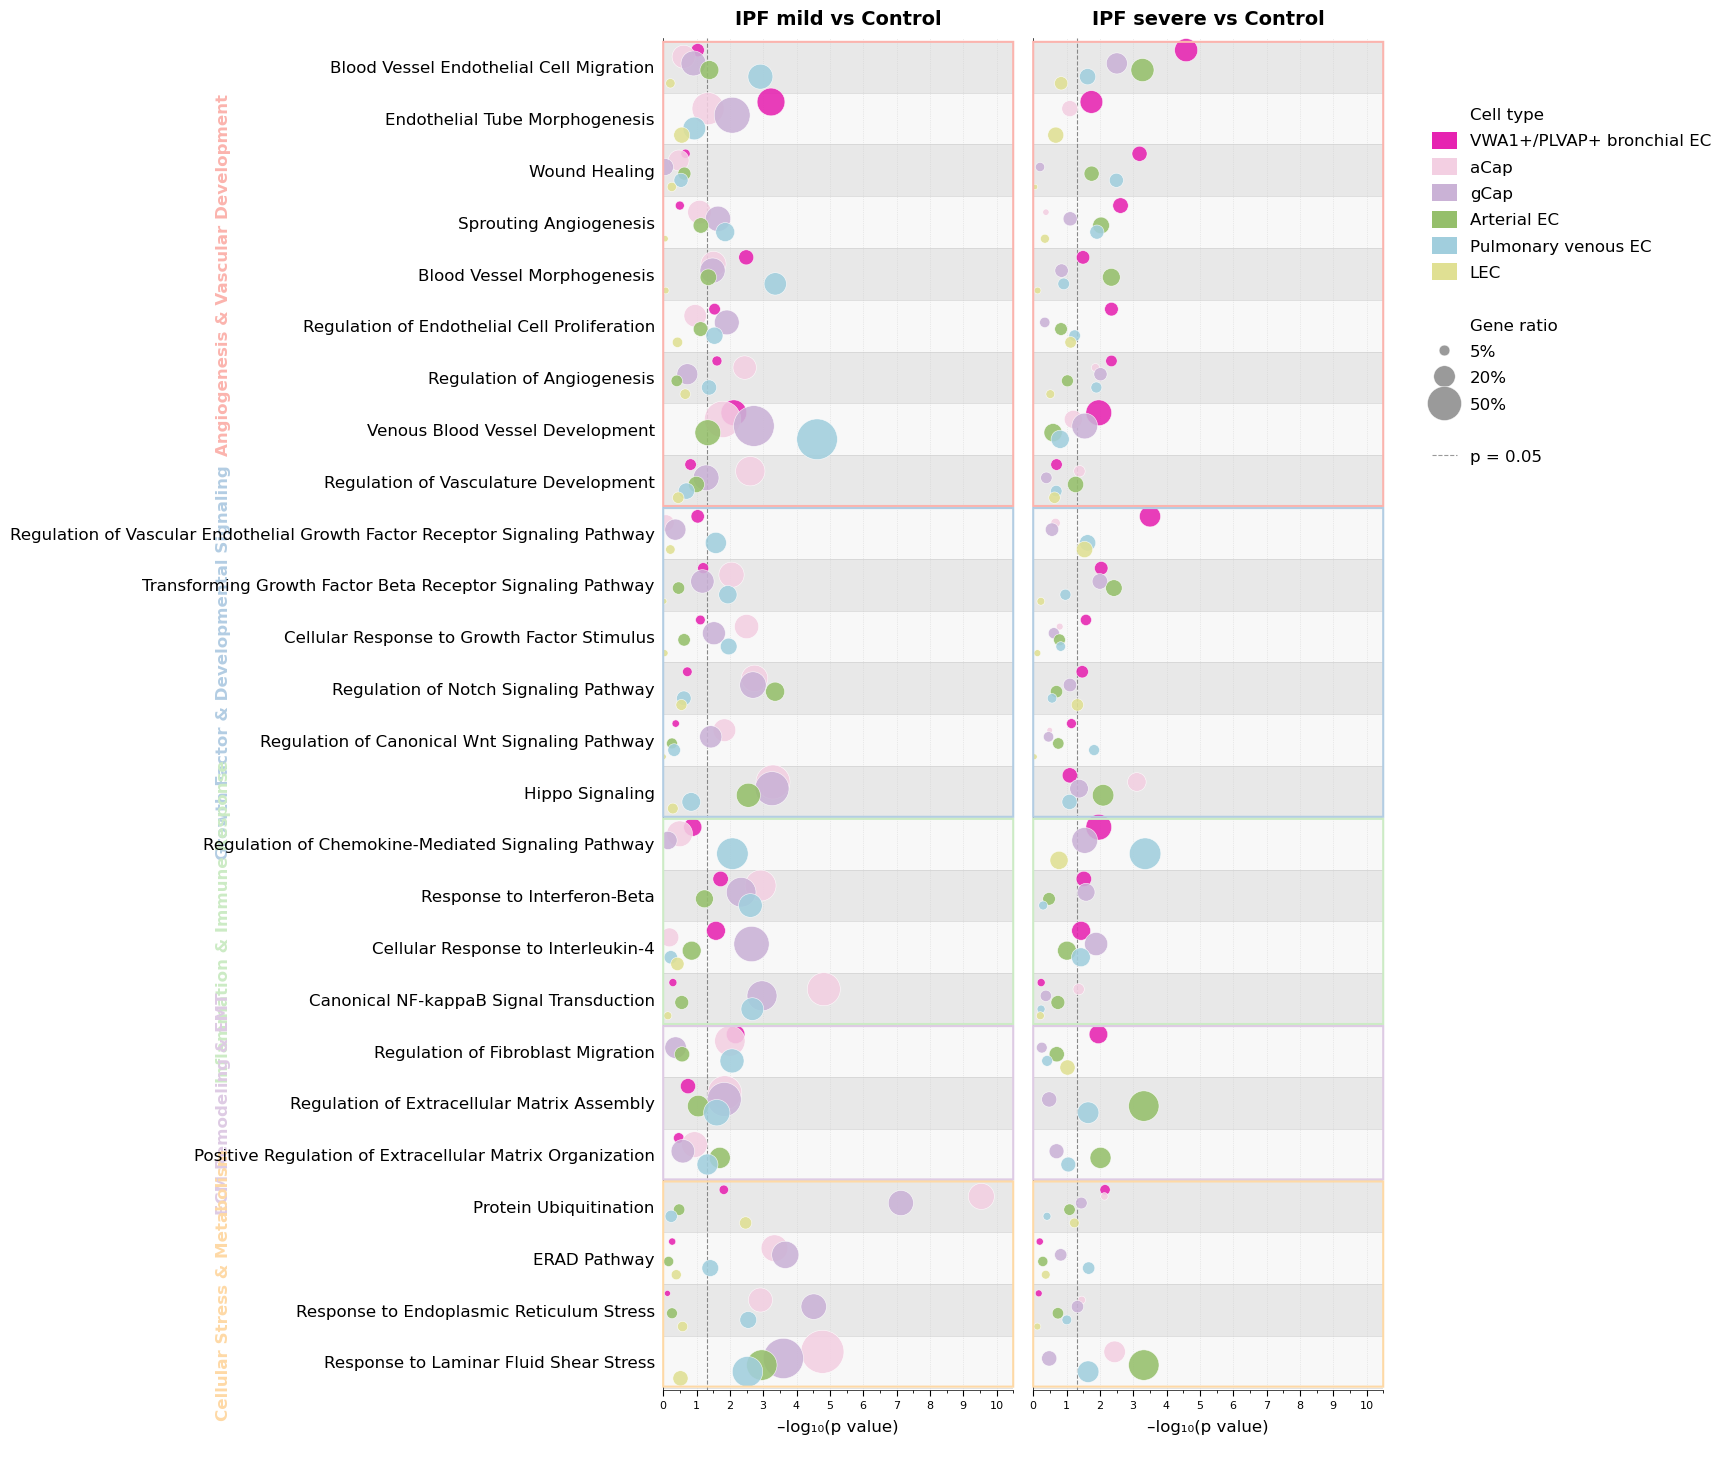

In [11]:
# ── 5. Compute significance & term ordering (ranked by PLVAP+/VWA1+ EC) ────────
plot_df["-log10p"]  = -np.log10(plot_df["pval"].clip(lower=1e-10))
plot_df["category"] = plot_df["Term"].map(category_map)

unmapped = plot_df[plot_df["category"].isna()]["Term"].unique()
if len(unmapped) > 0:
    print(f"\nWARNING: {len(unmapped)} matched terms have no category mapping:")
    for t in unmapped:
        print(f"  - {t}")

plvap_label = "VWA1+/PLVAP+ bronchial EC"
plvap_df = plot_df[plot_df["cell_type"] == plvap_label]

term_sig_plvap = (
    plvap_df.groupby("Term")["-log10p"]
    .max()
    .reset_index()
    .rename(columns={"-log10p": "plvap_sig"})
)

term_order_df = (
    plot_df[["Term", "category"]]
    .drop_duplicates(subset="Term")
    .reset_index(drop=True)
)
term_order_df = term_order_df.merge(term_sig_plvap, on="Term", how="left")
term_order_df["plvap_sig"] = term_order_df["plvap_sig"].fillna(-1)

term_order_df["cat_rank"] = term_order_df["category"].map(
    {c: i for i, c in enumerate(category_order)}
)
term_order_df = term_order_df.sort_values(
    ["cat_rank", "plvap_sig"], ascending=[True, False]
)
term_order = term_order_df["Term"].tolist()
n_terms    = len(term_order)
y_map      = {t: i for i, t in enumerate(term_order)}


# ── 6. Figure geometry ──────────────────────────────────────────────────────────
ROW_H     = 0.52
TOP_PAD   = 1.2
BOT_PAD   = 0.9
CAT_PAD   = 0.4
LEFT_PAD  = 4.2
RIGHT_PAD = 2
PANEL_W   = 3.5
GAP_W     = 0.2

fig_h = n_terms * ROW_H + TOP_PAD + BOT_PAD
fig_w = CAT_PAD + LEFT_PAD + 2 * PANEL_W + GAP_W + RIGHT_PAD

fig = plt.figure(figsize=(fig_w, fig_h))

cp = CAT_PAD  / fig_w
lp = LEFT_PAD / fig_w
pp = PANEL_W  / fig_w
gp = GAP_W    / fig_w
tp = TOP_PAD  / fig_h
bp = BOT_PAD  / fig_h
ph = 1 - tp - bp

ax_cat  = fig.add_axes([0,                  bp, cp, ph])
ax_mild = fig.add_axes([cp + lp,            bp, pp, ph])
ax_sev  = fig.add_axes([cp + lp + pp + gp,  bp, pp, ph])

ax_cat.set_xlim(0, 1)
ax_cat.set_ylim(-0.55, n_terms - 0.45)
ax_cat.invert_yaxis()
ax_cat.axis("off")

cat_spans = {}
for term in term_order:
    cat = category_map.get(term)
    yi  = y_map[term]
    if cat not in cat_spans:
        cat_spans[cat] = [yi, yi]
    else:
        cat_spans[cat][1] = yi

for cat in category_order:
    if cat not in cat_spans:
        continue
    y0, y1 = cat_spans[cat]
    fc = category_colors[cat]
    ax_cat.text(
        0.5, (y0 + y1) / 2,
        cat,
        ha="center", va="center",
        rotation=90,
        fontsize=12, fontweight="bold",
        color=fc,
        clip_on=False,
    )

max_x      = np.ceil(plot_df["-log10p"].max() * 1.1 * 2) / 2
ref_x      = -np.log10(0.05)
max_gc     = plot_df["overlap_ratio"].max()
# ── cell 6: fixed size scale for ratios in [0, 1] ────────────────────────────
size_scale = 1200    # ratio=1.0 → 400pt², ratio=0.25 → 100pt²


# ── 7. Panel-drawing function ────────────────────────────────────────────────────
def draw_panel(ax, condition, show_ylabels=True):
    sub = plot_df[plot_df["condition"] == condition]

    cat_spans_local = {}
    for term in term_order:
        cat = category_map.get(term)
        yi  = y_map[term]
        if cat not in cat_spans_local:
            cat_spans_local[cat] = [yi, yi]
        else:
            cat_spans_local[cat][1] = yi

    for cat in category_order:
        if cat not in cat_spans_local:
            continue
        y0, y1 = cat_spans_local[cat]
        fc = category_colors[cat]
        ax.axhspan(y0 - 0.5, y1 + 0.5,
                   facecolor=fc + "12", zorder=0, linewidth=0)
        rect = FancyBboxPatch(
            (0, y0 - 0.48), max_x, (y1 - y0) + 0.96,
            boxstyle="round,pad=0.0",
            linewidth=1.5, edgecolor=fc,
            facecolor="none", zorder=5,
            clip_on=False,
        )
        ax.add_patch(rect)

    # ── alternating row stripes — stronger contrast ───────────────────────────
    for i in range(n_terms):
        fc_row = "#e8e8e8" if i % 2 == 0 else "#f8f8f8"
        ax.axhspan(i - 0.5, i + 0.5,
                   facecolor=fc_row, alpha=1.0, zorder=1, linewidth=0)
     # ── thin separator lines between every row ────────────────────────────────
    for i in range(n_terms + 1):
        ax.axhline(i - 0.5, color="#cccccc", linewidth=0.4,
                   linestyle="-", zorder=2)     

    # ── raw p=0.05 reference line ─────────────────────────────────────────────────
    ax.axvline(ref_x, color="#888888", linewidth=0.8,
               linestyle="--", zorder=3)

    # ── bubbles ───────────────────────────────────────────────────────────────
    n_ct   = len(ct_order)
    jitter = np.linspace(-0.32, 0.32, n_ct)

    for ci, ct in enumerate(ct_order):
        s = sub[sub["cell_type"] == ct]
        if s.empty:
            continue
        ys = s["Term"].map(y_map) + jitter[ci]
        ax.scatter(
            s["-log10p"], ys,
            s          = s["overlap_ratio"] * size_scale,
            color      = cell_type_colors[ct],
            alpha      = 0.88,
            zorder     = 4,
            linewidths = 0.4,
            edgecolors = "white",
        )

    ax.set_xlim(0, max_x)
    ax.set_ylim(-0.55, n_terms - 0.45)
    ax.invert_yaxis()

    ax.set_yticks(range(n_terms))
    if show_ylabels:
        ax.set_yticklabels(term_order, fontsize=12)
    else:
        ax.set_yticklabels([])

    ax.set_xlabel("–log₁₀(p value)", fontsize=12, labelpad=6)
    ax.xaxis.set_major_locator(plt.MultipleLocator(1.0))
    ax.xaxis.set_minor_locator(plt.MultipleLocator(0.5))
    ax.tick_params(axis="x", labelsize=8, which="major", length=4)
    ax.tick_params(axis="x", which="minor", length=2)
    ax.tick_params(axis="y", length=0, pad=6)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_linewidth(0.5)
    ax.spines["bottom"].set_linewidth(0.5)

    ax.grid(axis="x", linestyle=":", linewidth=0.5,
            color="#cccccc", alpha=0.7, zorder=1)


draw_panel(ax_mild, "Mild",   show_ylabels=True)
draw_panel(ax_sev,  "Severe", show_ylabels=False)

for ax, title in [(ax_mild, "IPF mild vs Control"), (ax_sev, "IPF severe vs Control")]:
    ax.set_title(title, fontsize=14, fontweight="bold", pad=10)


# ── 8. Legend ───────────────────────────────────────────────────────────────────
legend_x = (CAT_PAD + LEFT_PAD + 2 * PANEL_W + GAP_W + 0.4) / fig_w 

ax_leg = fig.add_axes([legend_x, 0.02, RIGHT_PAD / fig_w - 0.02, ph])
ax_leg.axis("off")

handles = []

handles.append(mpatches.Patch(color="none", label="Cell type"))
for ct in ct_order:
    handles.append(mpatches.Patch(color=cell_type_colors[ct], label=ct, linewidth=0))

handles.append(mpatches.Patch(color="none", label=""))

# ── cell 8: legend shows ratio percentages ────────────────────────────────────
handles.append(mpatches.Patch(color="none", label="Gene ratio"))
for ratio, label in [(0.05, "5%"), (0.2, "20%"), (0.5, "50%")]:
    handles.append(
        ax_leg.scatter([], [], s=ratio * size_scale,
                       color="#888888", alpha=0.85,
                       linewidths=0.4, edgecolors="white",
                       label=label)
    )

handles.append(mpatches.Patch(color="none", label=""))

handles.append(
    plt.Line2D([0], [0], linestyle="--", color="#999999",
               linewidth=0.8, label="p = 0.05")
)

ax_leg.legend(
    handles=handles,
    loc="upper left", bbox_to_anchor=(0, 1),
    fontsize=12, frameon=False,
    handlelength=1.5, handleheight=1.2,
    borderpad=0, labelspacing=0.55,
)

# ── 9. Save ──────────────────────────────────────────────────────────────────────
plt.savefig(plot_folder + "EC_all_GO_bubble_up_pathway_overlap_ratio.pdf", bbox_inches="tight", dpi=300)
plt.show()